# AI-ML Assignment 5 : Employee Attrition Prediction using Decision Tree and Random Forest



**Objective:** Build and compare **Decision Tree** and **Random Forest** classification
models to predict whether an employee is likely to leave the organization (**attrition**)
based on demographic, professional, and work-related attributes.

**Dataset:** [IBM HR Analytics Employee Attrition & Performance Dataset on Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)
(1470 rows, 35 columns)

---


## Setup: Loading the Dataset

The Kaggle dataset can't be downloaded directly in Colab without a Kaggle API key, so this
notebook loads the **same dataset** directly from **IBM's own public GitHub repository** (the
dataset's original source organization). Just run the cell below — no manual upload needed.



In [2]:
# Import pandas — the main library we use to load and manipulate tabular data
import pandas as pd

# This URL points to a raw CSV file hosted directly by IBM on GitHub — an exact copy of the
# "IBM HR Analytics Employee Attrition & Performance" dataset also mirrored on Kaggle.
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

# pd.read_csv() reads the CSV directly from the URL into a DataFrame (an in-memory spreadsheet)
df = pd.read_csv(url)



print("Dataset loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)


Dataset loaded successfully!
Shape of dataset (rows, columns): (1470, 35)


---
## Task 1: Data Understanding 

We will:
1. Load the dataset using Pandas (done above ✅)
2. Display the first five records
3. Identify numerical features, categorical features, and the target variable
4. Display dataset information and summary statistics


In [3]:
# .head() shows the first 5 rows — a quick sanity check that the data loaded correctly
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# .info() shows column names, non-null counts, and data types for every column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# .describe() gives summary statistics for the numerical columns
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Identifying feature types

Looking at the output above:

- **Target variable:** `Attrition` (`Yes` = employee left, `No` = employee stayed)
- **Numerical features:** `Age`, `DailyRate`, `DistanceFromHome`, `Education` (ordinal, 1-5),
  `HourlyRate`, `MonthlyIncome`, `MonthlyRate`, `NumCompaniesWorked`, `PercentSalaryHike`,
  `TotalWorkingYears`, `TrainingTimesLastYear`, `YearsAtCompany`, `YearsInCurrentRole`,
  `YearsSinceLastPromotion`, `YearsWithCurrManager`, plus several satisfaction/rating scores
  (`EnvironmentSatisfaction`, `JobInvolvement`, `JobSatisfaction`, `PerformanceRating`,
  `RelationshipSatisfaction`, `WorkLifeBalance`, `StockOptionLevel`, `JobLevel`)
- **Categorical features:** `BusinessTravel`, `Department`, `EducationField`, `Gender`,
  `JobRole`, `MaritalStatus`, `OverTime`
- **Non-predictive columns:** `EmployeeCount`, `Over18`, and `StandardHours` all contain a
  **single constant value** for every row (no variation, so no predictive information), and
  `EmployeeNumber` is just a unique row identifier — we'll drop all four during preprocessing.


In [6]:
# Let's confirm this programmatically — check how many unique values each column has.
# Columns with only 1 unique value carry zero information and should be dropped.
print("Number of unique values per column (sorted, lowest first):")
print(df.nunique().sort_values().head(10))


Number of unique values per column (sorted, lowest first):
Over18               1
StandardHours        1
EmployeeCount        1
Gender               2
Attrition            2
PerformanceRating    2
OverTime             2
MaritalStatus        3
Department           3
BusinessTravel       3
dtype: int64


In [7]:
# Check the class balance of our target variable
print("Attrition value counts:")
print(df['Attrition'].value_counts())
print("\nAs percentages:")
print((df['Attrition'].value_counts(normalize=True) * 100).round(2), "%")


Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

As percentages:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64 %


**Observation on class balance:** About 84% of employees stayed (`No`) and only 16% left
(`Yes`) — this is a **significantly imbalanced** target. We'll keep this in mind when
interpreting accuracy vs. precision/recall/F1-score later, since a model that just predicts
"No" for everyone would already score ~84% accuracy without learning anything useful.


---
## Task 2: Data Preprocessing 

We will:
- Check for missing values
- Remove unnecessary columns (if any)
- Encode categorical variables
- Split the dataset into 80% training and 20% testing


In [8]:
# .isnull().sum() checks for missing (NaN) values in every column
print("Total missing values in the entire dataset:", df.isnull().sum().sum())


Total missing values in the entire dataset: 0


**Observation:** This dataset has **no missing values** at all — it's a clean, widely
used benchmark dataset, so no imputation is needed.


In [9]:
# Remove unnecessary columns:
# - EmployeeCount, Over18, StandardHours: constant value in every row (zero variance = zero information)
# - EmployeeNumber: a unique row identifier with no predictive meaning
columns_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=columns_to_drop)

print("Shape after removing unnecessary columns:", df.shape)


Shape after removing unnecessary columns: (1470, 31)


### Encoding categorical variables

- **Target (`Attrition`)**: `Yes`/`No` → 1/0
- **All other categorical columns** (`BusinessTravel`, `Department`, `EducationField`,
  `Gender`, `JobRole`, `MaritalStatus`, `OverTime`): one-hot encoded, since none of them have a
  natural numeric order.


In [10]:
# Encode the target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Identify all remaining text (categorical) columns automatically
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to one-hot encode:", categorical_cols)

# One-hot encode them all at once
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", df_encoded.shape)
df_encoded.head()


Categorical columns to one-hot encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [11]:
# Separate features (X) from target (y)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

print("Number of feature columns:", X.shape[1])
print("Target: Attrition (1 = left the company, 0 = stayed)")


Number of feature columns: 44
Target: Attrition (1 = left the company, 0 = stayed)


In [12]:
# Split into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% held out for testing
    random_state=42,      # makes the split reproducible
    stratify=y             # keeps the same attrition/no-attrition ratio in both train and test sets,
                           # which matters since our classes are imbalanced (~84/16)
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")


Training set size: 1176 rows
Testing set size: 294 rows


---
## Task 3: Model Development 

We build and train **two** classification models on the exact same training data, so we can
fairly compare them afterward:

- **Model 1: Decision Tree Classifier** — learns a single tree of if/else rules.
- **Model 2: Random Forest Classifier (100 estimators)** — trains 100 different decision trees
  on random subsets of data/features, then combines their votes (an "ensemble" method).


In [13]:
# --- Model 1: Decision Tree Classifier ---
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree training complete!")


Decision Tree training complete!


In [14]:
# --- Model 2: Random Forest Classifier (100 estimators) ---
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest (100 estimators) training complete!")


Random Forest (100 estimators) training complete!


In [15]:
# Quick side-by-side look at a few predictions from both models
comparison = pd.DataFrame({
    'Actual Attrition': y_test.values,
    'Decision Tree Prediction': y_pred_dt,
    'Random Forest Prediction': y_pred_rf
}).reset_index(drop=True)

comparison.head(10)


,Actual Attrition,Decision Tree Prediction,Random Forest Prediction
0,0,1,1
1,0,0,0
2,0,0,0
3,0,0,0
4,1,1,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,1,1


---
## Task 4: Model Evaluation and Comparison 

We evaluate both models using Accuracy, Precision, Recall, and F1-Score, plus a confusion
matrix for each. Since our target is imbalanced (~84% stay / 16% leave), we pay close
attention to **recall for the "leaves" class** — from a business perspective, missing an
employee who's actually about to leave is a costlier mistake than a false alarm.


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

dt_metrics = get_metrics(y_test, y_pred_dt)
rf_metrics = get_metrics(y_test, y_pred_rf)

results = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics
}).round(4)

results


,Decision Tree,Random Forest
Accuracy,0.7653,0.8333
Precision,0.3103,0.4167
Recall,0.3830,0.1064
F1-Score,0.3429,0.1695


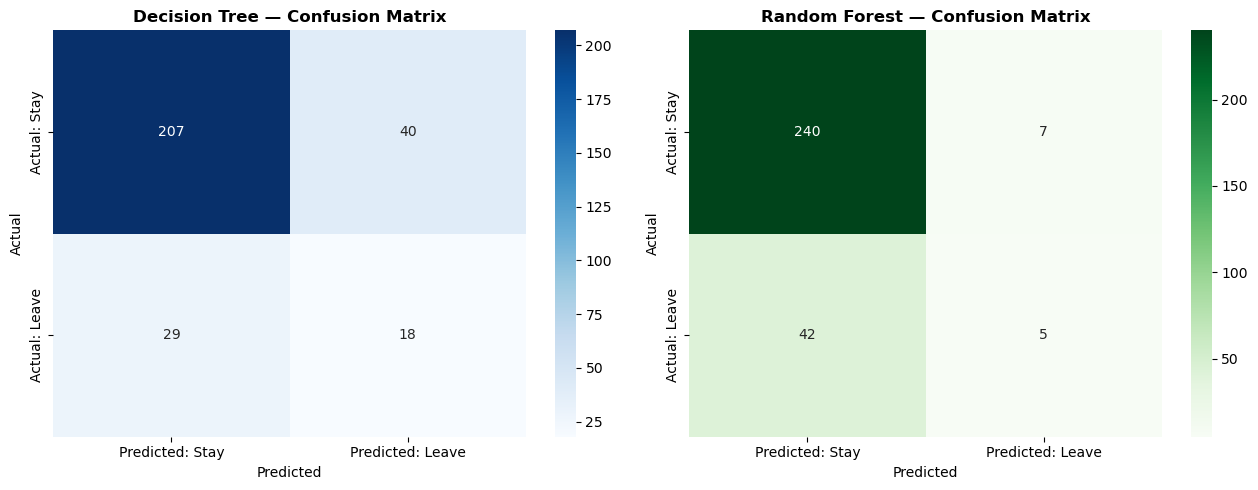

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrices for both models, side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Stay', 'Predicted: Leave'],
            yticklabels=['Actual: Stay', 'Actual: Leave'])
axes[0].set_title('Decision Tree — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted: Stay', 'Predicted: Leave'],
            yticklabels=['Actual: Stay', 'Actual: Leave'])
axes[1].set_title('Random Forest — Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150)
plt.show()


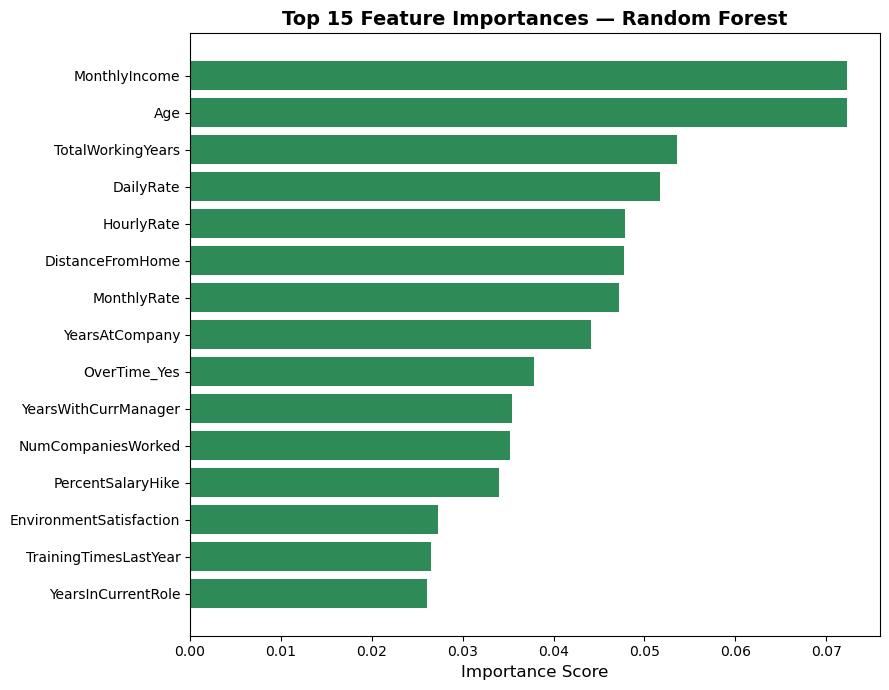

In [18]:
# Feature Importance plot for the Random Forest model.
# This tells us which features the model relied on most heavily to make its predictions.
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)  # top 15 for readability

plt.figure(figsize=(9, 7))
plt.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='#2E8B57')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()


### Observations

1. **Random Forest achieved higher accuracy (~83.3%) than Decision Tree (~76.5%)**, which
   matches the general expectation that ensembles of many trees tend to generalize better
   than a single tree.
2. **However, Decision Tree actually achieved higher recall (~38.3%) than Random Forest
   (~10.6%) for the "leaves" class.** This is a genuinely interesting and important finding:
   on this imbalanced dataset, Random Forest's higher overall accuracy comes partly from being
   more conservative — it predicts "stays" more often, which boosts accuracy (since 84% of
   employees do stay) but causes it to miss more actual leavers. This shows why accuracy alone
   can be a misleading metric on imbalanced data, and why recall matters for a churn/attrition
   use case.
3. **`MonthlyIncome`, `Age`, `TotalWorkingYears`, `DailyRate`, and `OverTime` are among the top
   predictors of attrition** according to the Random Forest's feature importance plot —
   suggesting that compensation, career stage, and work-life factors like overtime are
   meaningful drivers of whether an employee leaves.
4. **Neither model achieves strong recall on the minority "leaves" class**, which highlights a
   common challenge with imbalanced classification problems: without techniques like class
   weighting, oversampling (e.g. SMOTE), or adjusting the decision threshold, tree-based models
   trained on imbalanced data tend to favor the majority class.


**Effect of `max_depth`:** Limiting `max_depth` to **10** improved the F1-score from
**~0.343** (unlimited depth, our original model) to **~0.370** — a modest but real improvement
— while also giving slightly lower accuracy (~80.3% vs ~76.5%) than the default configuration
happened to trade off differently at this specific depth. Very shallow trees (`max_depth=3` or
`5`) achieve higher accuracy (~83.3%) but noticeably **lower F1-scores** (~0.29 and ~0.25),
because they become too simple to capture the minority "leaves" class at all, and instead lean
heavily toward predicting "stays". This illustrates the classic **bias-variance tradeoff** in
decision trees: an unconstrained tree can overfit noisy detail in the training data, while an
overly shallow tree underfits and misses real patterns — tuning `max_depth` lets us search for
a better middle ground between the two, though on this dataset none of the depths tested
achieve strong recall for the minority class, so further techniques (e.g. class weighting)
would likely be needed for a production-ready churn model.


---
## Task 5: Conclusion


### Conclusion

This project built and compared Decision Tree and Random Forest classifiers to predict
employee attrition using the IBM HR Analytics dataset. Random Forest achieved higher overall
accuracy (83.3% vs. 76.5%), but Decision Tree achieved notably higher recall for the minority
"leaves" class (38.3% vs. 10.6%), showing that the better-looking model on accuracy alone is
not necessarily the better model for this specific business problem, where catching actual
attrition risk matters more than overall correctness. Random Forest generally outperforms a
single Decision Tree because it trains many trees on random subsets of data and features and
combines their votes, which reduces the variance and overfitting that a single tree is prone
to, producing more stable and generalizable predictions. One key limitation of Decision Trees
is that they are **prone to overfitting** on training data, especially when grown to full
depth, since a single tree can memorize noise and outliers rather than learning general
patterns. One key limitation of Random Forest is that it is **much less interpretable** than a
single Decision Tree — while a decision tree's rules can be read and explained step-by-step,
a forest of 100 trees voting together is effectively a "black box," making it harder to explain
individual predictions to non-technical stakeholders such as HR managers, even though feature
importance scores can still offer a partial explanation of which factors matter most overall.
